# **Exercise 3 - Multimedia IR and Learning to Rank**

In this exercise session you will look at some implementations of concepts learnt in the lectures on multimedia information retrieval and learning to rank approaches.

### **Multimedia IR**

We will look at two models for multimedia IR - CNNs and transformer models.

With a CNN, we will only work with images, where we retrieve images based on similarity in features between the query image and document image. We will then look at briding modalities between text and image using transformer models.

The commonality here is that they both are ways to represent text and image in a comparable format, where the retrieval can happen based on the similarity between the query and document representations (recall vector-based models in exercise 1).

#### 1. CNN

Two types of CNN models for object detection and image classifcation have been implemented here - [VGG16](https://medium.com/@mygreatlearning/everything-you-need-to-know-about-vgg16-7315defb5918) and  [ResNet50](https://medium.com/@nitishkundu1993/exploring-resnet50-an-in-depth-look-at-the-model-architecture-and-code-implementation-d8d8fa67e46f). We will use these models to perform image retrieval using feature extraction. The idea here is to generate features for a dataset of images from the output layer of these models. We will then use cosine similarity to retrieve images with features that match those of a query image.

In [3]:
import numpy as np
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Reshape, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import ResNet50
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import cv2
import numpy as np
import pandas as pd

Clone the data - this repo contains the [CINIC-50](https://github.com/BayesWatch/cinic-10) dataset (and other datasets you will need for this exercise session), consisting of 90,000 images from 10 categories. In the interest of time and compute, we will use a reduced version of 1000 images to generate our features. The repo also contains a full version - in case you want to try it out.

In [4]:
!git clone https://github.com/kushaltatariya/Exercise_3.git

Cloning into 'Exercise_3'...
remote: Enumerating objects: 263633, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 263633 (delta 16), reused 69 (delta 14), pack-reused 263562 (from 1)
Receiving objects: 100% (263633/263633), 699.63 MiB | 32.68 MiB/s, done.
Resolving deltas: 100% (13671/13671), done.
Updating files: 100% (273030/273030), done.


In [5]:
train_directory = "/content/Exercise_3/CINIC-reduced/train"
valid_directory = "/content/Exercise_3/CINIC-reduced/valid"
test_directory = "/content/Exercise_3/CINIC-reduced/test"

In [6]:
img_rows = 224
img_cols = 224
input_shape = (img_rows, img_cols, 3)

epochs = 10
batch_size = 64

num_of_classes = 10

num_of_train_samples = 900
num_of_valid_samples = 900
num_of_test_samples = 900

In [7]:
# Normalization with (rescale=1./255)
train_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(directory=train_directory,
                                                                         class_mode='categorical',
                                                                         batch_size=batch_size,
                                                                         target_size=(img_rows, img_cols),
                                                                         color_mode="rgb",
                                                                         shuffle=True)

# Normalization with (rescale=1./255)
valid_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(directory=valid_directory,
                                                                         class_mode='categorical',
                                                                         batch_size=batch_size,
                                                                         target_size=(img_rows, img_cols),
                                                                         color_mode="rgb",
                                                                         shuffle=True)

Found 1000 images belonging to 10 classes.
Found 1000 images belonging to 10 classes.


In [12]:
def getVGG16Model(lastFourTrainable=False):
    vgg_model = VGG16(weights='imagenet', input_shape=input_shape, include_top=True)

    # Make all layers untrainable
    for layer in vgg_model.layers[:]:
        layer.trainable = False

    # Add fully connected layer which have 1024 neuron to VGG-16 model
    output = vgg_model.get_layer('fc2').output
    output = Flatten(name='new_flatten')(output)
    output = Dense(units=1024, activation='relu', name='new_fc')(output)
    output = Dense(units=10, activation='softmax')(output)
    vgg_model = Model(vgg_model.input, output)

    # Make last 4 layers trainable if lastFourTrainable == True
    if lastFourTrainable == True:
        vgg_model.get_layer('block5_conv3').trainable = True
        vgg_model.get_layer('fc1').trainable = True
        vgg_model.get_layer('fc2').trainable = True
        vgg_model.get_layer('new_fc').trainable = True

    # Compile VGG-16 model
    vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    vgg_model.summary()

    return vgg_model

In [9]:
def getResNet50Model(lastFourTrainable=False):
    resnet_model = ResNet50(weights='imagenet', input_shape=input_shape, include_top=True)

    # Make all layers non-trainable
    for layer in resnet_model.layers[:]:
        layer.trainable = False

    # Add fully connected layer with 1024 neurons to ResNet-50 model
    output = resnet_model.get_layer('avg_pool').output
    output = Flatten(name='new_flatten')(output)
    output = Dense(units=1024, activation='relu', name='new_fc')(output)
    output = Dense(units=10, activation='softmax')(output)
    resnet_model = Model(resnet_model.input, output)

    # Make last 4 layers trainable if lastFourTrainable == True
    if lastFourTrainable == True:
        resnet_model.get_layer('conv5_block3_2_bn').trainable = True
        resnet_model.get_layer('conv5_block3_3_conv').trainable = True
        resnet_model.get_layer('conv5_block3_3_bn').trainable = True
        resnet_model.get_layer('new_fc').trainable = True

    resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    resnet_model.summary()

    return resnet_model

In [10]:
def getFeatureVector(model, img_path):
    """Get feature vector of an image by given model and img_path"""
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    feature_vector = model.predict(img.reshape(1, 224, 224, 3))
    return feature_vector


def getCosineSimilarity(A, B):
    """Get cosine similarity between feature vectors A and B using cosine similarity"""
    cos_similarity = np.dot(A, B.T) / (np.linalg.norm(A) * np.linalg.norm(B))
    return cos_similarity[0][0]


def getFeatureDataFrame(model):
    df = pd.DataFrame(columns=['file', 'features'])
    train_files = train_generator.filepaths
    valid_files = valid_generator.filepaths
    files = train_files + valid_files

    df['file'] = files
    df['features'] = df.apply(lambda row: getFeatureVector(model, row['file']), axis=1)

    print("All files added.")
    return df

def getSimilarImages(img_file, features_df, model, model_name):
    """Get and plot 5 similar images for given image path and features dataframe"""
    img_features = getFeatureVector(model, img_file)
    features_df['similarity'] = features_df.apply(lambda row: getCosineSimilarity(img_features, np.asarray(row['features'])), axis=1)
    sorted_df = features_df.sort_values(by='similarity', ascending=False)
    return sorted_df

In [13]:
vgg_model_a = getVGG16Model(lastFourTrainable=False)
feature_model_vgg_a = Model( inputs=vgg_model_a.input, outputs=vgg_model_a.get_layer('new_fc').output)

df = getFeatureDataFrame(feature_model_vgg_a)
df.to_pickle("features_vgg_a.pickle")

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc1 (Dense)                          │ (None, 4096)                │     102,764,544 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 138,466,122 (528.21 MB)

 Trainable params: 4,205,578 (16.04 MB)

 Non-trainable params: 134,260,544 (512.16 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 583ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 983ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 616ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 924ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [14]:
df

,file,features
0,/content/Exercise_3/CINIC-reduced/train/airpla...,"[[4.5853415, 0.0, 0.657211, 2.963454, 0.0, 0.0..."
1,/content/Exercise_3/CINIC-reduced/train/airpla...,"[[2.6667933, 0.0, 0.0, 2.129795, 0.0, 0.0, 2.3..."
2,/content/Exercise_3/CINIC-reduced/train/airpla...,"[[1.8902861, 0.0, 0.80882066, 1.0401255, 0.0, ..."
3,/content/Exercise_3/CINIC-reduced/train/airpla...,"[[1.2952203, 0.0, 0.8300465, 1.9734911, 0.0, 0..."
4,/content/Exercise_3/CINIC-reduced/train/airpla...,"[[2.097088, 0.0, 0.27077156, 0.47990745, 0.0, ..."
...,...,...
1995,/content/Exercise_3/CINIC-reduced/valid/truck/...,"[[0.6083564, 0.0, 1.3676999, 2.086855, 0.0, 0...."
1996,/content/Exercise_3/CINIC-reduced/valid/truck/...,"[[0.12856726, 2.1706884, 0.0, 2.5459065, 0.218..."
1997,/content/Exercise_3/CINIC-reduced/valid/truck/...,"[[1.4921739, 0.0, 0.016017694, 0.77019197, 0.0..."
1998,/content/Exercise_3/CINIC-reduced/valid/truck/...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.8792868, 0.0..."


Get the test files (possible query images)

In [15]:
feature_test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(directory=test_directory,
                                                                  class_mode='categorical',
                                                                  batch_size=batch_size,
                                                                  target_size=(img_rows, img_cols),
                                                                  color_mode="rgb",
                                                                  shuffle=False)
feature_test_files = feature_test_generator.filepaths

Found 1000 images belonging to 10 classes.


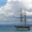

In [16]:
from IPython.display import Image, display

display(Image(feature_test_files[800], width = 100, height = 100))

In [17]:
query_file = feature_test_files[800]
df = pd.read_pickle('features_vgg_a.pickle')
df_results = getSimilarImages(query_file, df, feature_model_vgg_a, 'VGG-16 (a)')
df_results

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 614ms/step


,file,features,similarity
1821,/content/Exercise_3/CINIC-reduced/valid/ship/c...,"[[2.778154, 0.0, 0.0, 1.3693242, 0.0, 0.0, 3.4...",0.832713
1806,/content/Exercise_3/CINIC-reduced/valid/ship/c...,"[[2.522405, 0.0, 0.45862204, 1.3371873, 0.0, 0...",0.821454
1822,/content/Exercise_3/CINIC-reduced/valid/ship/c...,"[[2.4038963, 0.0, 0.56543386, 1.1274077, 0.0, ...",0.820867
402,/content/Exercise_3/CINIC-reduced/train/deer/c...,"[[3.8586664, 0.0, 0.0, 0.0, 0.0, 0.0, 0.428139...",0.813232
57,/content/Exercise_3/CINIC-reduced/train/airpla...,"[[2.2769175, 0.0, 0.0, 0.9384986, 0.0, 0.0, 2....",0.804012
...,...,...,...
696,/content/Exercise_3/CINIC-reduced/train/frog/n...,"[[0.93421274, 0.0, 4.12518, 2.201024, 0.0, 0.0...",0.430985
922,/content/Exercise_3/CINIC-reduced/train/truck/...,"[[0.0, 0.0, 0.20303164, 0.6405254, 0.0, 0.0, 0...",0.430066
624,/content/Exercise_3/CINIC-reduced/train/frog/n...,"[[0.0, 0.0, 3.0257547, 2.143065, 0.0, 0.0, 1.6...",0.426567
682,/content/Exercise_3/CINIC-reduced/train/frog/n...,"[[0.84418786, 0.0, 1.6592044, 1.4540005, 0.0, ...",0.419345


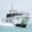

In [18]:
most_similar = df_results['file'].to_list()[0]
display(Image(most_similar))

Try doing the above steps with the ResNet50 model - what difference do you see?

In [19]:
resnet = getResNet50Model(lastFourTrainable=False)
feature_model_resnet = Model( inputs=resnet.input, outputs=resnet.get_layer('new_fc').output)

df = getFeatureDataFrame(feature_model_resnet)
df.to_pickle("features_resnet.pickle")

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 25,696,138 (98.02 MB)

 Trainable params: 2,108,426 (8.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [21]:
query_file = feature_test_files[800]
df = pd.read_pickle('features_resnet.pickle')
df_results = getSimilarImages(query_file, df, feature_model_resnet, 'VGG-16 (a)')
df_results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


,file,features,similarity
1806,/content/Exercise_3/CINIC-reduced/valid/ship/c...,"[[0.57391363, 0.0, 0.0, 0.0, 0.25592446, 1.339...",0.843237
818,/content/Exercise_3/CINIC-reduced/train/ship/c...,"[[0.5302215, 1.3115559, 0.0, 0.0, 0.14041048, ...",0.817771
1801,/content/Exercise_3/CINIC-reduced/valid/ship/c...,"[[0.4161176, 0.0, 0.10548832, 0.0, 0.14471242,...",0.806852
1823,/content/Exercise_3/CINIC-reduced/valid/ship/c...,"[[0.0, 0.0, 0.027049754, 0.0, 0.0, 1.1362146, ...",0.805572
22,/content/Exercise_3/CINIC-reduced/train/airpla...,"[[0.5379268, 0.006437913, 0.0, 0.0, 0.42911327...",0.796052
...,...,...,...
684,/content/Exercise_3/CINIC-reduced/train/frog/n...,"[[0.0, 0.0, 0.0, 0.12555955, 0.0, 0.32935414, ...",0.489168
381,/content/Exercise_3/CINIC-reduced/train/cat/n0...,"[[0.0, 1.0596504, 0.0, 0.0, 2.3634167, 0.79023...",0.487729
1366,/content/Exercise_3/CINIC-reduced/valid/cat/n0...,"[[0.0, 0.68785214, 0.0, 0.0, 0.0, 0.0, 0.0, 1....",0.486636
1224,/content/Exercise_3/CINIC-reduced/valid/bird/n...,"[[0.0, 0.0, 0.0, 0.13944077, 0.31092098, 0.893...",0.480122


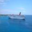

In [22]:
most_similar = df_results['file'].to_list()[0]
display(Image(most_similar))

If you are interested in exploring approaches that combine text and image modalities using CNNs - you can have a look at [DSCMR](https://github.com/penghu-cs/DSCMR/tree/master) - Deep Supervised Cross-Modal Retrieval. You should be able to replicate their results just by cloning the repo and running `main.py`.

#### **2. Cross-Modal Retrieval with CLIP**

[CLIP](https://github.com/openai/CLIP) jointly trains an image encoder and a text encoder to predict the correct pairings of a batch of (image, text) training examples, effectively forming the ability to bridge both modalities. Various vision transformer architectures can be loaded within this network.

In this section we will look at a CLIP-based retrieval system that allows us to query with text and image.

#### **Task**

Explore the [clip-retrieval](https://github.com/rom1504/clip-retrieval/tree/main) repository. There is example code that you can play with to understand the implementation, in particular:

- [notebook/clip-client-query-api.ipynb](https://github.com/rom1504/clip-retrieval/blob/main/notebook/clip-client-query-api.ipynb)
- [notebook/retrieval_example.ipynb](https://github.com/rom1504/clip-retrieval/blob/main/notebook/retrieval_example.ipynb)

Here you can try out different types of queries - both image and text. These notebooks contain good examples of cross-modal retrieval. You can even compare the same query images as we used for the CNN models.

### **Learning to Rank**

In this section we look at implementations of various learning to rank models. We start with a basic machine learning model called LightGBM, and then move to neural models.

LightGBM uses [LambdaRank](https://towardsdatascience.com/introduction-to-ranking-algorithms-4e4639d65b8) objective function for the ranking.

We will use normalised Discounted Cumulative Gain to evaluate the model (nDCG). [nDCG](https://towardsdatascience.com/how-to-evaluate-learning-to-rank-models-d12cadb99d47) is a ranking metric which measures the gain of a document regarding in what’s it’s position: a relevant document placed within the first positions (at the top) will have a greater gain than a relevant document placed at the bottom.

We will use the [MQ2008](https://www.microsoft.com/en-us/research/project/letor-learning-rank-information-retrieval/) dataset by Microsoft that is a learning to rank dataset with 800 queries and relevant documents.

In [47]:
import lightgbm as lgb
gbm = lgb.LGBMRanker()

In [48]:
from sklearn.datasets import load_svmlight_file
import numpy as np

X_train, y_train, qid_train = load_svmlight_file(str('Exercise_3/MQ2008/Fold1/train.txt'), query_id=True)
X_test, y_test, qid_test = load_svmlight_file(str('Exercise_3/MQ2008/Fold1/test.txt'), query_id=True)

y_train = y_train.astype(int)
y_test = y_test.astype(int)

_, group_train = np.unique(qid_train, return_counts=True)

gbm.fit(X_train, y_train, group=group_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002892 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9233
[LightGBM] [Info] Number of data points in the train set: 9630, number of used features: 40


LGBMRanker()

In [49]:
predictions = []

for group in np.unique(qid_test):
    preds = gbm.predict(X_test[qid_test == group])
    predictions.extend(preds)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [50]:
def dcg(y_score, y_true, k):
    """DCG evaluation function. Note the importance of sorting by score!"""
    order = np.argsort(y_score)[::-1]
    y_true = np.take(y_true, order[:k])

    gains = 2 ** y_true - 1
    discounts = np.log2(np.arange(len(y_true)) + 2)

    return np.sum(gains / discounts)

def ndcg(y_score, y_true, k):
    """nDCG evaluation function"""
    dcg_ = dcg(y_score, y_true, k)
    idcg = dcg(y_true, y_true, k)

    return dcg_ / idcg

In [51]:
qids = np.unique(qid_test)

In [52]:
ndcg_ = list()

for i, qid in enumerate(qids):
    y = y_test[qid_test == qid]

    if np.sum(y) == 0:
        continue

    p = gbm.predict(X_test[qid_test == qid])

    ndcg_.append(ndcg(p, y, k=10))

In [53]:
print(f"Model score: {np.mean(ndcg_)}")

Model score: 0.707093563768135


#### **Task - Neural Models**

Explore the [allRank](https://github.com/allegro/allRank/tree/master) repo that contains a PyTorch-based framework for training neural learning to rank models.
Run the following to set up the repo and run experiments:


```
!git clone https://github.com/allegro/allRank.git
!pip install -r allRank/requirements.txt
%cd allRank
%env PYTHONPATH="$/env/python:/content/allRank/
!pip install tensorboardX
!pip install flatten-dict
```

You can train neural learning to rank models in different configurations using the same dataset we used above. You can either use the predefined configuration files in `reproducibility/configs` or create your own!

You will have to change the datapath in the config file to point to MQ2008 filepath:


```
"data": {
    "path": "MLSR-WEB30K-FOLD1-PATH",

to:

"data": {
  "path": "/content/Exercise_3/MQ2008/Fold1/"

```

And change the number of epochs to not train the model for too long!!

An example run looks like:

```
!python allrank/main.py --config-file-name reproducibility/configs/neuralndcg_web30k/lambdarank_atmax.json \
--run-id test_1 --job-dir /content/
```

Observe the difference in training times, evaluation scores and other variables in the different configurations. You can also play around with different hyperparameters like number of epochs, learning rates or evaluation metrics.

In [54]:
!git clone https://github.com/allegro/allRank.git
!pip install -r allRank/requirements.txt
%cd allRank
%env PYTHONPATH="$/env/python:/content/allRank/
!pip install tensorboardX
!pip install flatten-dict

Cloning into 'allRank'...
remote: Enumerating objects: 653, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 653 (delta 197), reused 182 (delta 182), pack-reused 406 (from 1)
Receiving objects: 100% (653/653), 149.75 KiB | 3.57 MiB/s, done.
Resolving deltas: 100% (427/427), done.
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.9/210.9 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 4.3 MB/s eta 0:00:00
  Created wheel for flake8-blind-except: filename=flake8_blind_except-0.1.1-py3-none-any.w

In [55]:
!python allrank/main.py --config-file-name reproducibility/configs/neuralndcg_web30k/lambdarank_atmax.json \
--run-id test_1 --job-dir /content/

will read config from reproducibility/configs/neuralndcg_web30k/lambdarank_atmax.json
[INFO] 2025-04-01 12:03:45 - created paths container PathsContainer(local_base_output_path='/content/', base_output_path='/content/', output_dir='/content/results/test_1', tensorboard_output_path='/content/tb_evals/single/test_1', config_path='reproducibility/configs/neuralndcg_web30k/lambdarank_atmax.json')
[INFO] 2025-04-01 12:03:45 - Config:
 {'click_model': None,
 'data': DataConfig(path='/content/Exercise_3/MQ2008/Fold1/', num_workers=1, batch_size=64, slate_length=240, validation_ds_role='test'),
 'detect_anomaly': False,
 'expected_metrics': {'val': {'ndcg_5': 0.5}},
 'loss': NameArgsConfig(name='lambdaLoss', args={'weighing_scheme': 'lambdaRank_scheme', 'k': None, 'mu': 10, 'sigma': 1.0}),
 'lr_scheduler': NameArgsConfig(name='StepLR', args={'step_size': 50, 'gamma': 0.1}),
 'metrics': defaultdict(<class 'list'>,
                        {'ndcg': [5,
                                  10,
      

#### **Bonus: Neural LTR model with contextualised embeddings**

[CEDR (Contextualised Embeddings for Document Ranking)](https://github.com/Georgetown-IR-Lab/cedr/tree/master) uses BERT classification for document ranking and show that BERT embeddings can be used by prior neural ranking architectures to further improve ranking performance.

You can explore the repo if interested, it contains good documentation on how to train BERT models for document ranking with [TREC](https://trec.nist.gov/data/webmain.html).

### Sources

https://medium.com/analytics-vidhya/cnn-transfer-learning-with-vgg-16-and-resnet-50-feature-extraction-for-image-retrieval-with-keras-53320c580853

https://tamaracucumides.medium.com/learning-to-rank-with-lightgbm-code-example-in-python-843bd7b44574

